<a href="https://colab.research.google.com/github/Samarthsinha789/LoRa-Network-Coverage-Prediction-Using-ML/blob/main/MinorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the LoRa dataset
df = pd.read_csv('LoRa_Receiver_Data.csv')

# Display first few rows
df.head()

,dist_km,SF,BW_kHz,TxPower_dBm,env,PathLoss_dB,Shadowing_dB,Fading_dB,OtherLosses_dB,RSSI_dBm,Noise_dBm,SNR_dB,PDR,Coverage
0,6.609923,10,250,10,suburban,107.586022,-2.523157,1.277784,8.061988,-104.402636,-115.326075,10.923439,0.991457,Good
1,9.100787,12,250,17,rural,110.363673,1.771790,9.102776,2.188471,-106.426711,-114.146459,7.719748,0.944373,Moderate
2,9.029328,10,250,2,suburban,110.295203,4.503212,3.106502,6.108907,-122.013824,-112.359823,-9.654001,0.000504,Poor
3,3.969465,8,125,5,suburban,103.156733,5.392304,-3.076579,6.820286,-107.292745,-118.266277,10.973533,0.991708,Good
4,6.164141,8,500,2,suburban,106.979545,6.060991,0.059792,6.779056,-117.879384,-112.372078,-5.507306,0.006033,Poor


In [ ]:
# Step 3: Create Coverage Quality Labels based on SNR values
def classify_quality(snr):
    if snr > 6:
        return 'Good'
    elif snr > 2:
        return 'Moderate'
    else:
        return 'Poor'

df['Coverage'] = df['SNR_dB'].apply(classify_quality)

# View counts
df['Coverage'].value_counts()


,count
Coverage,
Good,1431
Poor,371
Moderate,198


In [ ]:
# Step 4: Prepare features (X) and labels (y)
X = df[['dist_km','SF','BW_kHz','TxPower_dBm']]
y = df['Coverage']

# Split into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Step 6: Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.6625

Classification Report:
               precision    recall  f1-score   support

        Good       0.77      0.82      0.80       250
    Moderate       0.37      0.37      0.37        86
        Poor       0.57      0.42      0.49        64

    accuracy                           0.66       400
   macro avg       0.57      0.54      0.55       400
weighted avg       0.66      0.66      0.66       400




MODEL : Decision Tree Classifier

Accuracy: 0.5925

Classification Report:
               precision    recall  f1-score   support

        Good       0.77      0.76      0.76       250
    Moderate       0.29      0.34      0.31        86
        Poor       0.35      0.30      0.32        64

    accuracy                           0.59       400
   macro avg       0.47      0.46      0.47       400
weighted avg       0.60      0.59      0.59       400



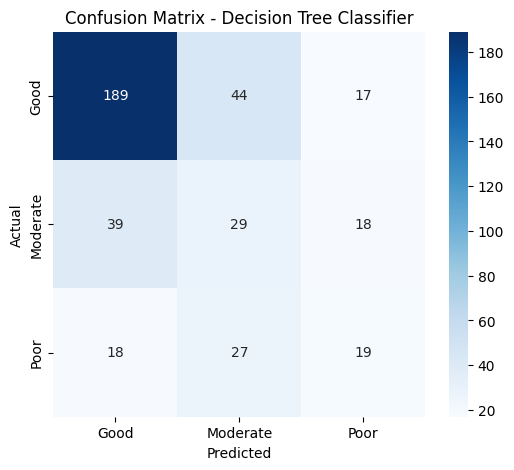


MODEL : Random Forest Classifier

Accuracy: 0.6625

Classification Report:
               precision    recall  f1-score   support

        Good       0.77      0.82      0.80       250
    Moderate       0.37      0.37      0.37        86
        Poor       0.57      0.42      0.49        64

    accuracy                           0.66       400
   macro avg       0.57      0.54      0.55       400
weighted avg       0.66      0.66      0.66       400



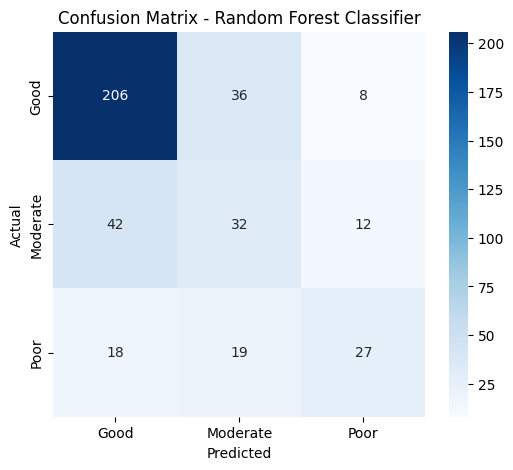


MODEL : Logistic Regression Classifier



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.705

Classification Report:
               precision    recall  f1-score   support

        Good       0.75      0.92      0.83       250
    Moderate       0.48      0.33      0.39        86
        Poor       0.68      0.36      0.47        64

    accuracy                           0.70       400
   macro avg       0.64      0.54      0.56       400
weighted avg       0.68      0.70      0.68       400



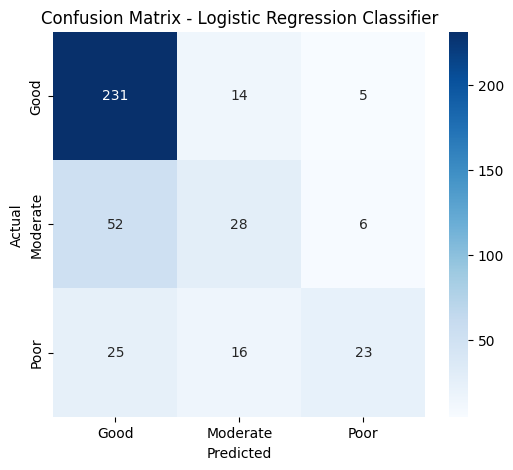

In [ ]:
# ---------------------------------------------
# IMPORT LIBRARIES
# ---------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# ---------------------------------------------
# LOAD DATA
# ---------------------------------------------
df = pd.read_csv("LoRa_Receiver_Data.csv")

# Convert coverage labels if needed
df['Coverage'] = df['Coverage'].astype(str)

# ---------------------------------------------
# FEATURES & LABELS
# ---------------------------------------------
X = df[['dist_km', 'SF', 'BW_kHz', 'TxPower_dBm']]
y = df['Coverage']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ************************************************************
# FUNCTION TO TRAIN, PREDICT, PRINT ACCURACY & CONFUSION MATRIX
# ************************************************************
def evaluate_model(model, model_name):

    print("\n==============================================")
    print(f"MODEL : {model_name}")
    print("==============================================\n")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Good','Moderate','Poor'],
        yticklabels=['Good','Moderate','Poor']
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# ************************************************************
# RUN ALL MODELS
# ************************************************************
evaluate_model(DecisionTreeClassifier(), "Decision Tree Classifier")

evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42),
               "Random Forest Classifier")

evaluate_model(LogisticRegression(max_iter=500),
               "Logistic Regression Classifier")


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Store results here
results = []

# List of models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500)
}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Classification report (dict)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extract precision for each class
    good_p = report['Good']['precision'] if 'Good' in report else 0
    moderate_p = report['Moderate']['precision'] if 'Moderate' in report else 0
    poor_p = report['Poor']['precision'] if 'Poor' in report else 0

    # Save results
    results.append([name, acc, good_p, moderate_p, poor_p])

# Create comparison dataframe
comparison_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision_Good", "Precision_Moderate", "Precision_Poor"
])

# Show table
comparison_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision_Good,Precision_Moderate,Precision_Poor
0,Decision Tree,0.5800,0.763485,0.280374,0.346154
1,Random Forest,0.6625,0.774436,0.367816,0.574468
2,Logistic Regression,0.7050,0.750000,0.482759,0.676471


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Features and target
X = df[['dist_km','SF','BW_kHz','TxPower_dBm']]
y = df['SNR_dB']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1️⃣ Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

# 2️⃣ Decision Tree Regression
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))

# 3️⃣ Random Forest Regression
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

# Print comparison
print("\n----- RMSE Comparison -----")
print(f"Linear Regression RMSE       : {rmse_lr:.4f}")
print(f"Decision Tree Regression RMSE: {rmse_dt:.4f}")
print(f"Random Forest Regression RMSE: {rmse_rf:.4f}")



----- RMSE Comparison -----
Linear Regression RMSE       : 10.0723
Decision Tree Regression RMSE: 13.1254
Random Forest Regression RMSE: 10.5738


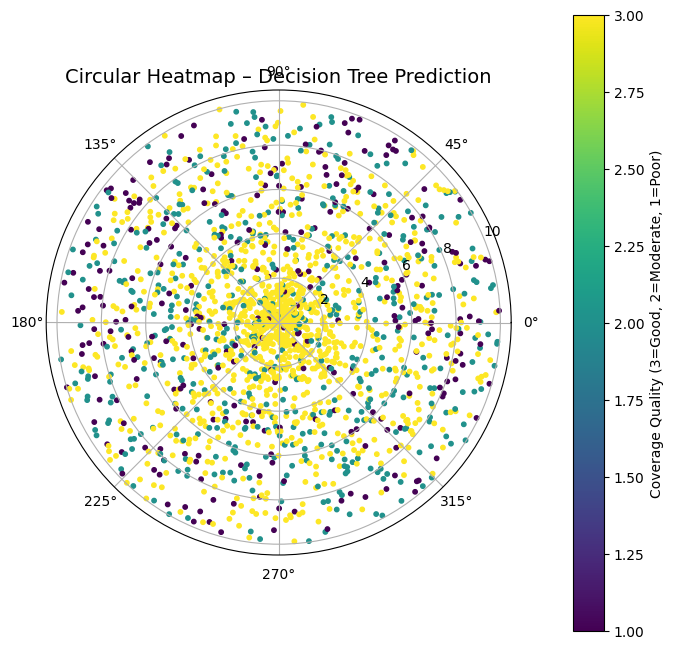

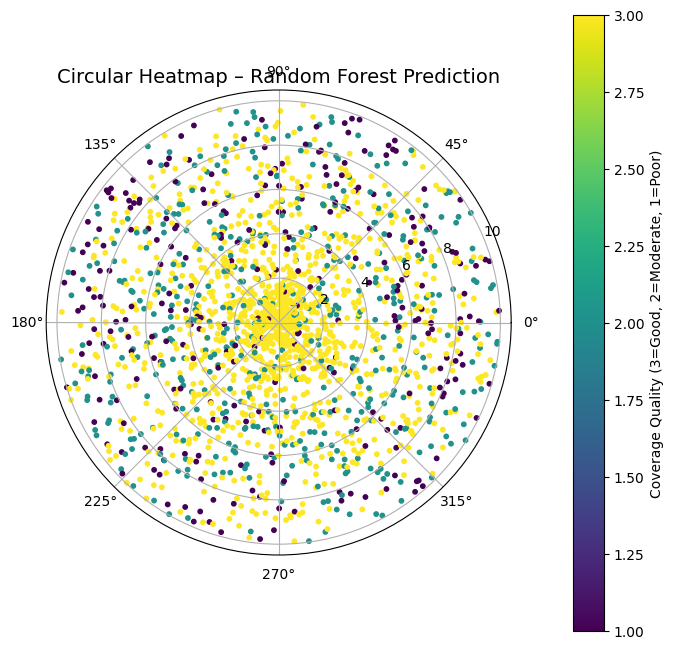

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


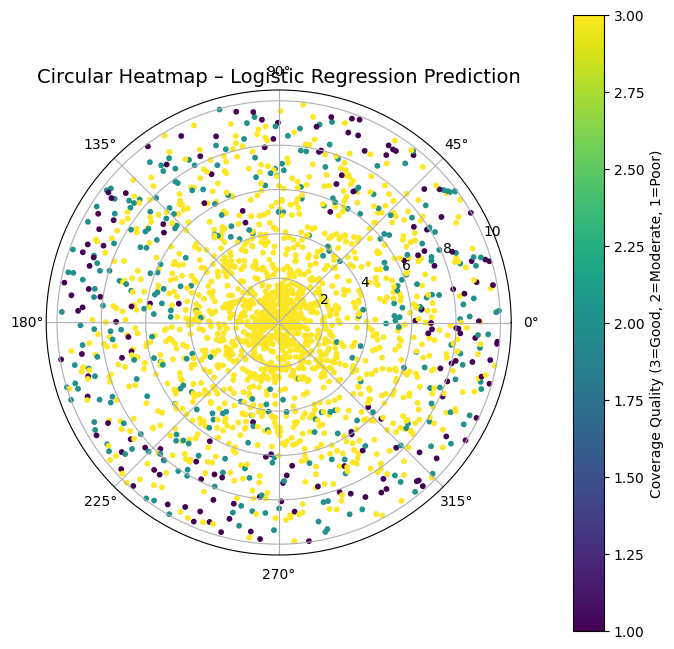

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ---------------------------------------
# Load Dataset (if not already loaded correctly)
# ---------------------------------------
df = pd.read_csv("LoRa_Receiver_Data.csv")

# ---------------------------------------
# Prepare features and labels for classification
# ---------------------------------------
X = df[['dist_km', 'SF', 'BW_kHz', 'TxPower_dBm']]
y = df['Coverage'] # Set y to the classification target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------
# Coverage mapping for color
# ---------------------------------------
coverage_map = {"Good": 3, "Moderate": 2, "Poor": 1}

# ---------------------------------------
# List of ML models
# ---------------------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500)
}

# ---------------------------------------
# Generate Circular Heatmap for each model
# ---------------------------------------
for name, model in models.items():

    # Train model with classification target
    model.fit(X_train, y_train)

    # Predict on full dataset for visualization
    df["Predicted"] = model.predict(df[['dist_km','SF','BW_kHz','TxPower_dBm']])
    df["PredictedVal"] = df["Predicted"].map(coverage_map)

    # Prepare circular coordinates
    theta = np.linspace(0, 2*np.pi, len(df))
    r = df["dist_km"]
    c = df["PredictedVal"]

    # Plot
    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, projection='polar')

    scatter = ax.scatter(theta, r, c=c, cmap='viridis', s=10)

    plt.title(f"Circular Heatmap – {name} Prediction", fontsize=14)
    cbar = plt.colorbar(scatter, pad=0.1)
    cbar.set_label("Coverage Quality (3=Good, 2=Moderate, 1=Poor)")

    plt.show()